# **Taller Práctico 03 — Inteligencia Geo-Temporal y de Redes**

## Optimización de Activos Críticos

**Maestría en Ciencia de Datos y Analítica — Universidad EAFIT**  
Curso: Fundamentos en Ciencia de Datos | Docente: Jorge Iván Padilla-Buriticá
Periodo académico 2026-2 

## Fase 1: Data Understanding y Geo-Visualización

### Tarea 1: Exploración Geo-Temporal

In [90]:
## Librerias

import pandas as pd 
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from scipy import signal
import networkx as nx
from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import seaborn as sns


In [91]:
## Carga datos
df_agro = pd.read_csv(r'..\data\raw\agro\agro_clean.csv')
df_agro_noise = pd.read_csv(r'..\data\raw\agro\agro_noise.csv')

df_ener = pd.read_csv(r'..\data\raw\ener\ener_clean.csv')
df_ener_noise = pd.read_csv(r'..\data\raw\ener\ener_noise.csv')

In [92]:
## Renombrar Columnas DFs

cols_agro = {
    'Agro_1' : 'Humedad', 
    'Agro_2' : 'Evaporacion', 
    'Agro_3' : 'RH', 
    'Agro_4' : 'Radiacion PAR', 
    'Agro_5' : 'NDVI', 
    'Agro_6' : 'Biomasa', 
    #'Agro_7' : '',
    'Agro_8' : 'Ruido', 
    #'Agro_9' : '', 
    'Agro_10' : 'Varianza Viento'
}

cols_ener = {
    'Ener_1' : 'Demanda', 
    'Ener_2' : 'Precio', 
    'Ener_3' : 'Temperatura', 
    'Ener_4' : 'Gen. Eolica', 
    'Ener_5' : 'Costo Gas', 
    'Ener_6' : 'Emisiones CO2', 
 #   'Ener_7' : '',
    'Ener_8' : 'Frecuencia', 
    'Ener_9' : 'Voltaje', 
    'Ener_10' : 'Potencia'
}


df_agro = df_agro.rename(columns=cols_agro)
df_agro_noise = df_agro_noise.rename(columns=cols_agro)

df_ener = df_ener.rename(columns=cols_ener)
df_ener_noise = df_ener_noise.rename(columns=cols_ener)

In [ ]:
## Mapa de Calor

fig = px.scatter_map(
    df_agro, 
    lat="Latitude", 
    lon="Longitude",
    color="NDVI", 
    size="Humedad",
    color_continuous_scale="RdYlGn",
    zoom=10.5,
    title="Sensores Agro (color=NDVI, tamaño=Humedad)", 
    height=700
)

fig.show()

**Análisis: ¿Existe algún patrón espacial (clustering) donde la biomasa sea consistentemente baja?**

No se identifica un patrón espacial de clustering donde la biomasa sea consistentemente baja, la ubicación de valores bajos parece ser aleatoria, lo que significa que las causas de baja biomasa probablemente están relacionadas con factores locales por sensor más que con una zona geográfica en especifico.

### Tarea 2: Análisis de Estacionariedad y Windowing

In [98]:
adf_results = []
non_stationary_cols = []

for col in df_ener.columns:
    series = df_ener[col].dropna()
    
    # Test ADF con selección automática de rezagos basada en AIC
    stat, p_value, usedlag, nobs, crit_vals, icbest = adfuller(series, autolag='AIC')
    
    is_stationary = p_value < 0.05
    if not is_stationary:
        non_stationary_cols.append(col)
        
    adf_results.append({
        'Serie': col,
        'Estadístico ADF': round(stat, 4),
        'p-valor': p_value,
        'Valor Crítico (5%)': round(crit_vals['5%'], 4),
        'Estacionaria': 'Sí' if is_stationary else 'No'
    })

# Convertir resultados a DataFrame
df_adf_summary = pd.DataFrame(adf_results)
df_adf_summary

,Serie,Estadístico ADF,p-valor,Valor Crítico (5%),Estacionaria
0,Demanda,-1.866900e+00,0.347793,-2.863,No
1,Precio,-1.479100e+00,0.543807,-2.863,No
2,Temperatura,-1.928400e+00,0.318802,-2.863,No
3,Gen. Eolica,-1.336821e+10,0.000000,-2.863,Sí
4,Costo Gas,-3.477000e-01,0.918470,-2.863,No
5,Emisiones CO2,9.527000e-01,0.993741,-2.863,No
6,Ener_7,-4.244000e-01,0.905937,-2.863,No
7,Frecuencia,-4.603630e+01,0.000000,-2.863,Sí
8,Voltaje,-4.535820e+01,0.000000,-2.863,Sí
9,Potencia,-4.371510e+01,0.000000,-2.863,Sí


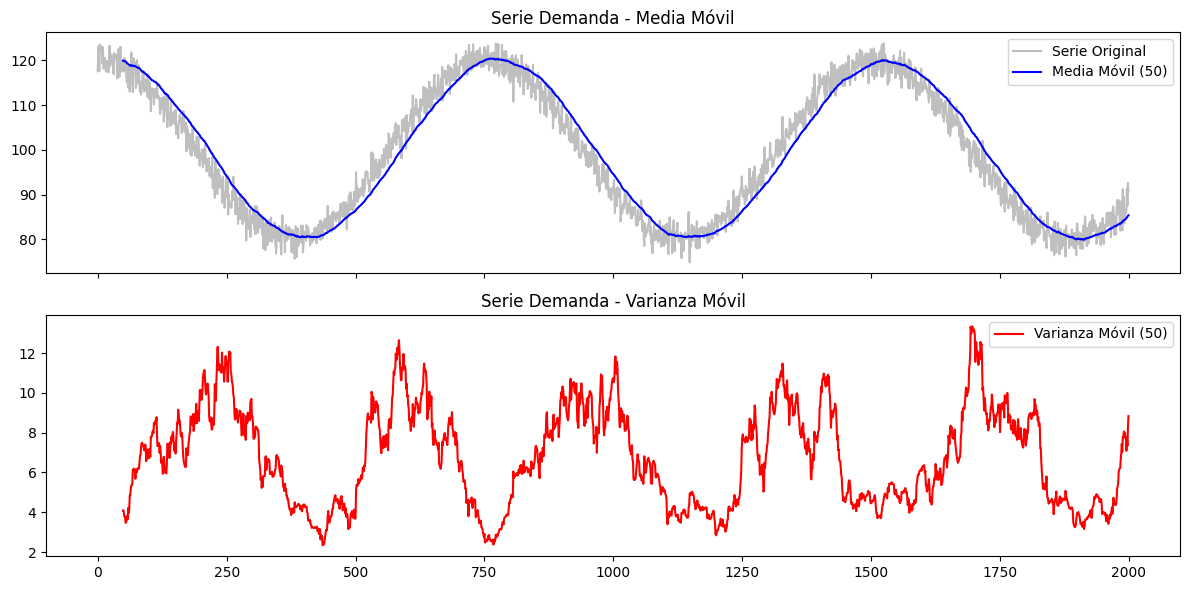

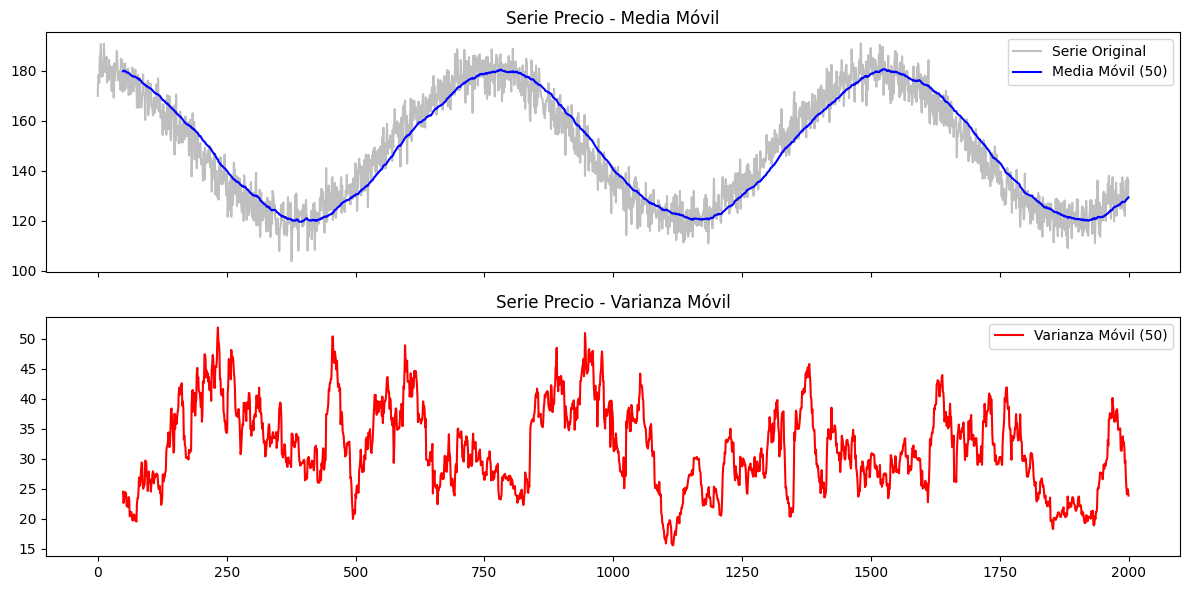

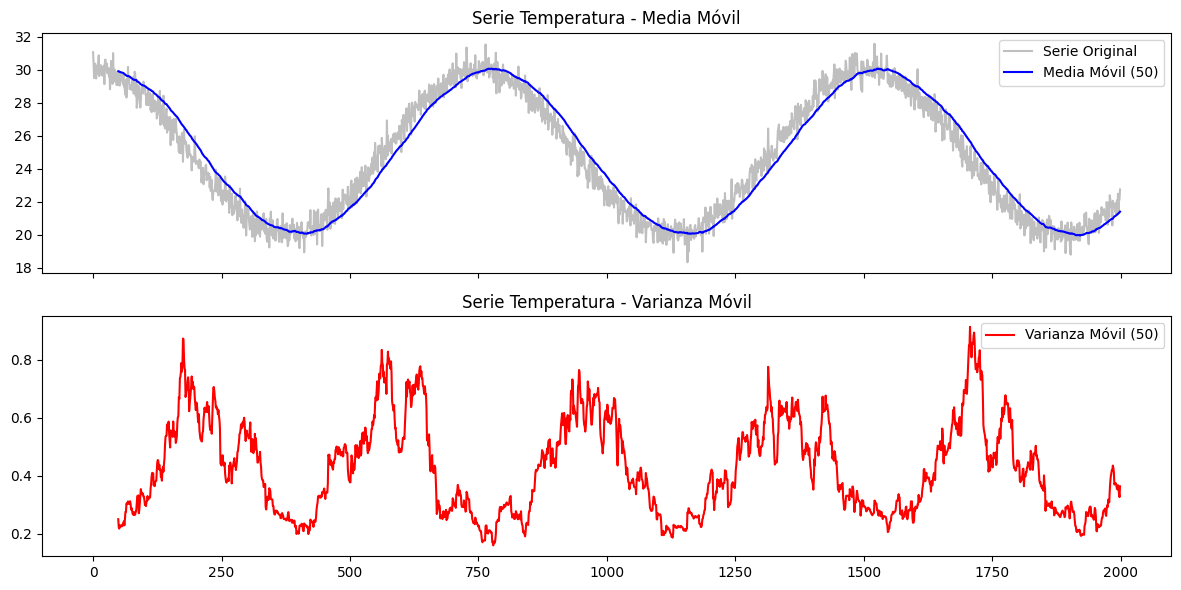

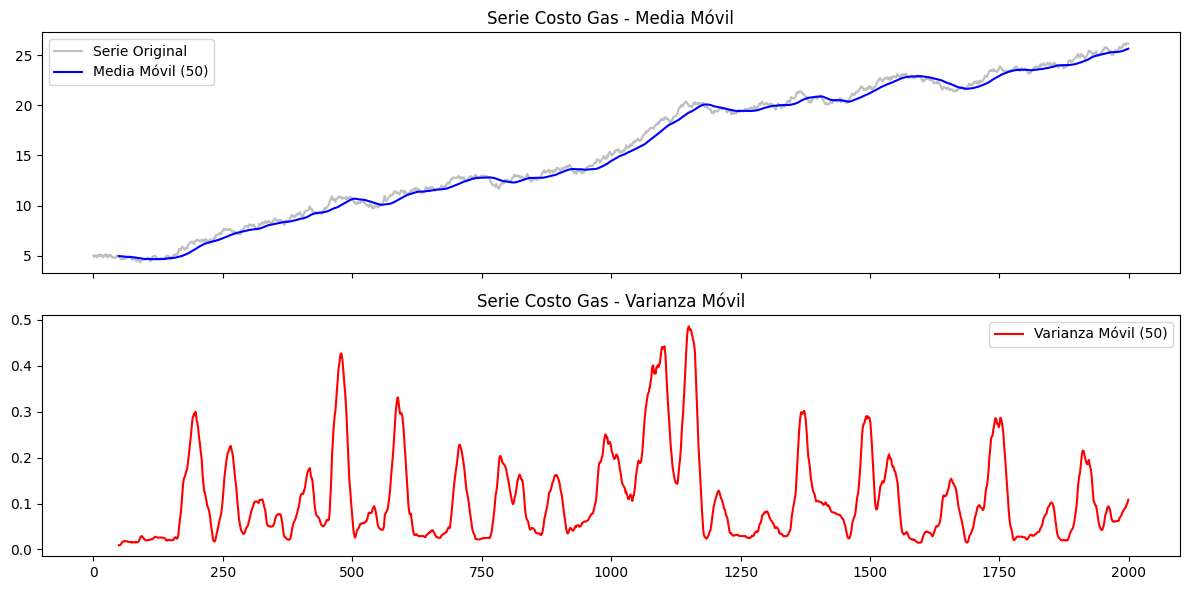

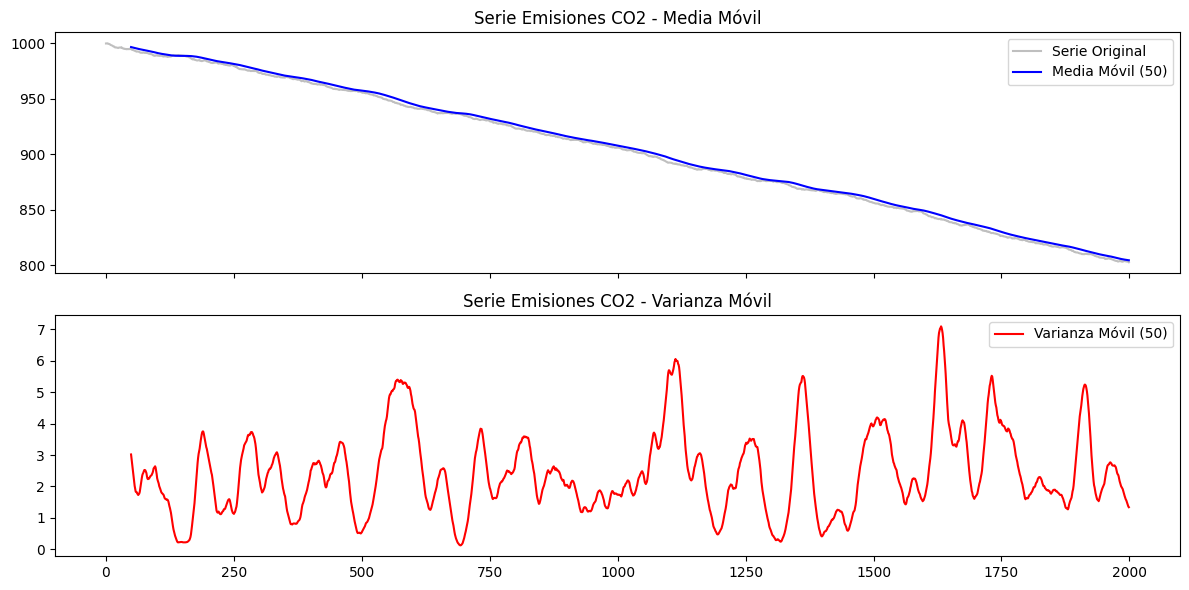

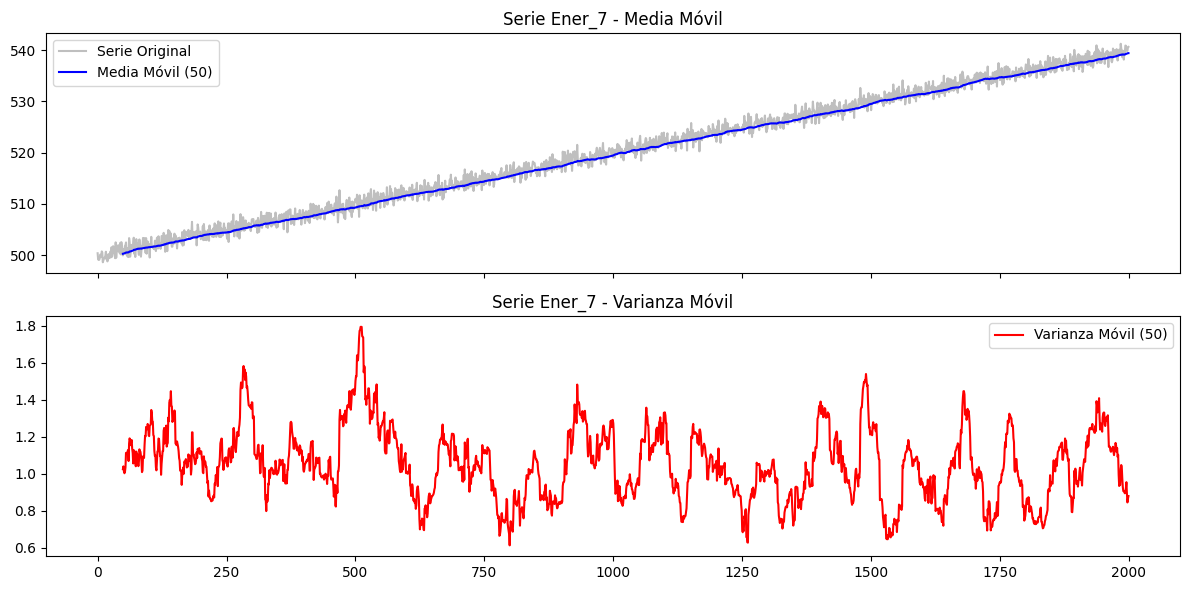

In [99]:
window_size = 50

if len(non_stationary_cols) > 0:
    for col in non_stationary_cols:
        df_ener[f'{col}_Media_Movil'] = df_ener[col].rolling(window=window_size).mean()
        df_ener[f'{col}_Varianza_Movil'] = df_ener[col].rolling(window=window_size).var()
        
        # Graficar media y varianza móvil
        fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        
        ax[0].plot(df_ener[col], label='Serie Original', color='gray', alpha=0.5)
        ax[0].plot(df_ener[f'{col}_Media_Movil'], label=f'Media Móvil ({window_size})', color='blue')
        ax[0].set_title(f'Serie {col} - Media Móvil')
        ax[0].legend()
        
        ax[1].plot(df_ener[f'{col}_Varianza_Movil'], label=f'Varianza Móvil ({window_size})', color='red')
        ax[1].set_title(f'Serie {col} - Varianza Móvil')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()
else:
    print("Todas las series resultaron ser estacionarias al nivel alpha = 0.05.")

--- PRUEBAS ESPECÍFICAS ADF EN Costo Gas ---
Sin constante (n): Estadístico = 4.1696, p-valor = 1.0000e+00
Con Drift (c):     Estadístico = -0.3477, p-valor = 9.1847e-01
Con Tendencia (ct):Estadístico = -2.3625, p-valor = 3.9974e-01

Media de las primeras diferencias (Drift estimado): 0.010560


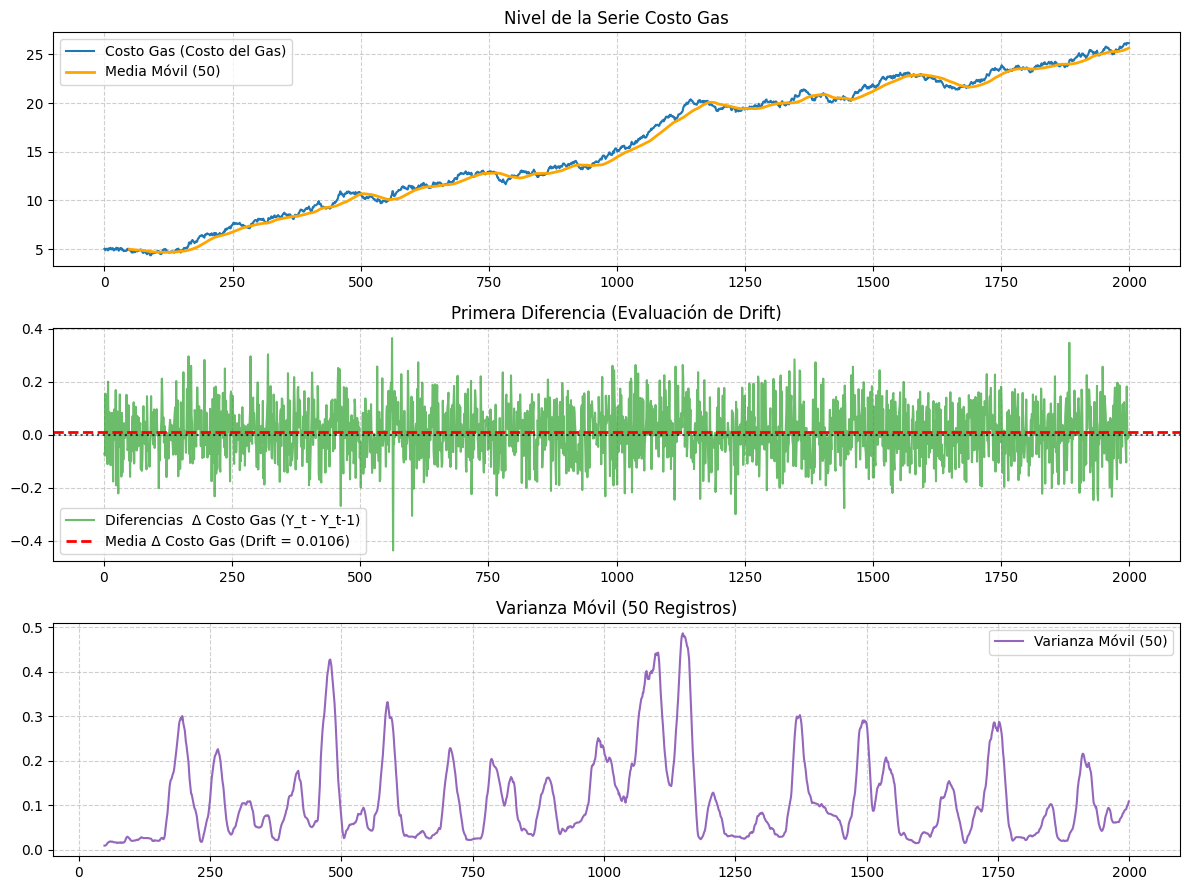

In [100]:
ener5 = df_ener['Costo Gas'].dropna()
diff_ener5 = ener5.diff().dropna()

# 1. Ajuste de especificaciones ADF para Costo Gas
res_n = adfuller(ener5, regression='n')   # Sin constante (Pure Random Walk)
res_c = adfuller(ener5, regression='c')   # Con constante/drift
res_ct = adfuller(ener5, regression='ct') # Con constante y tendencia lineal

print("--- PRUEBAS ESPECÍFICAS ADF EN Costo Gas ---")
print(f"Sin constante (n): Estadístico = {res_n[0]:.4f}, p-valor = {res_n[1]:.4e}")
print(f"Con Drift (c):     Estadístico = {res_c[0]:.4f}, p-valor = {res_c[1]:.4e}")
print(f"Con Tendencia (ct):Estadístico = {res_ct[0]:.4f}, p-valor = {res_ct[1]:.4e}")

mean_diff = diff_ener5.mean()
print(f"\nMedia de las primeras diferencias (Drift estimado): {mean_diff:.6f}")

# 2. Visualización
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

# Subplot 1: Serie Costo Gas y Media Móvil (50)
axes[0].plot(ener5, color='tab:blue', label='Costo Gas (Costo del Gas)')
axes[0].plot(ener5.rolling(50).mean(), color='orange', linewidth=2, label='Media Móvil (50)')
axes[0].set_title('Nivel de la Serie Costo Gas')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Primeras Diferencias (Δ Costo Gas) y su Drift Estimado
axes[1].plot(diff_ener5, color='tab:green', alpha=0.7, label='Diferencias  Δ Costo Gas (Y_t - Y_t-1)')
axes[1].axhline(mean_diff, color='red', linestyle='--', linewidth=2, label=f'Media Δ Costo Gas (Drift = {mean_diff:.4f})')
axes[1].axhline(0, color='black', linestyle=':', alpha=0.7)
axes[1].set_title('Primera Diferencia (Evaluación de Drift)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

# Subplot 3: Varianza Móvil (50) de la Serie en Nivel
axes[2].plot(ener5.rolling(50).var(), color='tab:purple', label='Varianza Móvil (50)')
axes[2].set_title('Varianza Móvil (50 Registros)')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Fase 2: Procesamiento de Señales y Filtrado


### Tarea 3: Análisis Espectral (FFT) y Espectrogramas

In [101]:
N = len(df_ener['Gen. Eolica'])
fs = 1.0

In [102]:
snr_db = 8.0  # Seleccionado dentro de [5, 12] dB

# Potencia media de la señal eólica limpia
p_signal = np.mean(df_ener['Gen. Eolica']**2)

# Potencia del ruido derivada de la relación SNR: SNR = 10 * log10(P_signal / P_noise)
p_noise = p_signal / (10 ** (snr_db / 10.0))
noise_std = np.sqrt(p_noise)

# Generación del ruido gaussiano
np.random.seed(42)  # Para reproducibilidad
noise = np.random.normal(0, noise_std, size=N)

# Serie con ruido inyectado
ener4_noise = df_ener['Gen. Eolica'] + noise

print(f"Potencia de la Señal: {p_signal:.2f}")
print(f"Potencia del Ruido (8 dB): {p_noise:.2f} (Desviación estándar: {noise_std:.2f})")

Potencia de la Señal: 1766.52
Potencia del Ruido (8 dB): 279.97 (Desviación estándar: 16.73)


In [103]:
# Frecuencias asociadas a la FFT (rango Nyquist [0, 0.5])
freqs = np.fft.rfftfreq(N, d=1/fs)

# Transformada de Fourier
fft_clean = np.fft.rfft(df_ener['Gen. Eolica'])
fft_noise = np.fft.rfft(ener4_noise)

# Densidad Espectral de Potencia (PSD)
psd_clean = (np.abs(fft_clean)**2) / (N * fs)
psd_noise = (np.abs(fft_noise)**2) / (N * fs)

In [104]:

nperseg = 128
noverlap = 64

# Espectrogramas para la serie limpia y ruidosa
f_clean, t_clean, Sxx_clean = signal.spectrogram(df_ener['Gen. Eolica'], fs=fs, nperseg=nperseg, noverlap=noverlap)
f_noise, t_noise, Sxx_noise = signal.spectrogram(ener4_noise, fs=fs, nperseg=nperseg, noverlap=noverlap)

# Diferencia espectral en escala decibélica (dB)
diff_spec = 10 * np.log10(Sxx_noise + 1e-12) - 10 * np.log10(Sxx_clean + 1e-12)

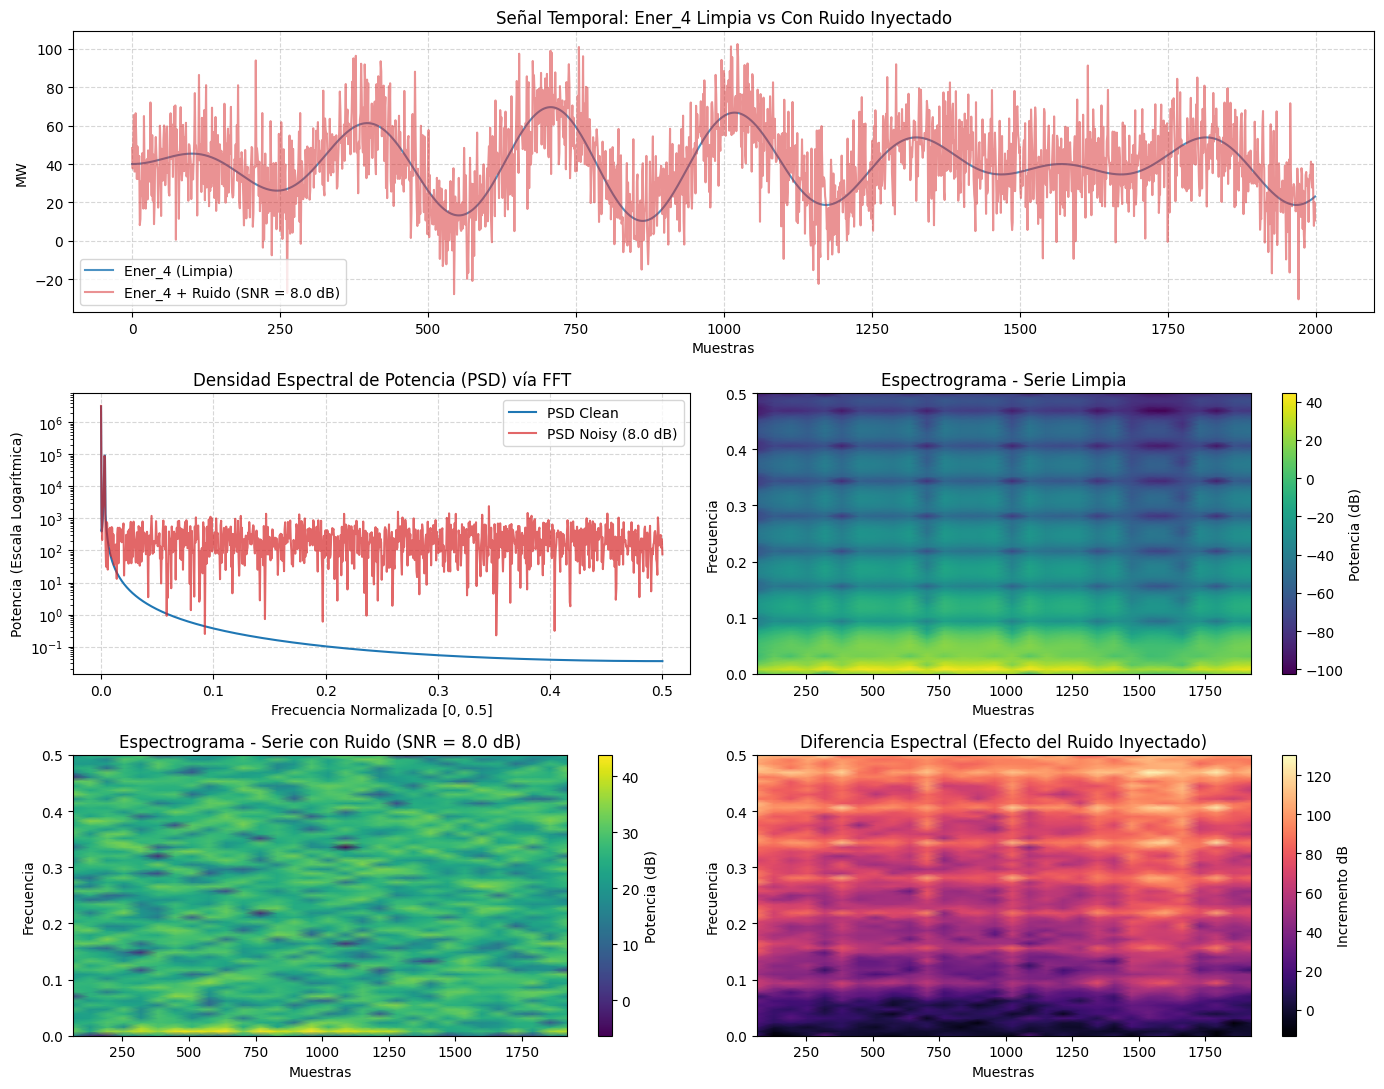

In [105]:
fig = plt.figure(figsize=(14, 11))

# 1. Señal Temporal
ax1 = plt.subplot(3, 2, (1, 2))
ax1.plot(df_ener['Gen. Eolica'], label='Ener_4 (Limpia)', color='tab:blue', alpha=0.8)
ax1.plot(ener4_noise, label=f'Ener_4 + Ruido (SNR = {snr_db} dB)', color='tab:red', alpha=0.5)
ax1.set_title('Señal Temporal: Ener_4 Limpia vs Con Ruido Inyectado')
ax1.set_xlabel('Muestras')
ax1.set_ylabel('MW')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Densidad Espectral de Potencia (PSD)
ax2 = plt.subplot(3, 2, 3)
ax2.semilogy(freqs, psd_clean, label='PSD Clean', color='tab:blue')
ax2.semilogy(freqs, psd_noise, label=f'PSD Noisy ({snr_db} dB)', color='tab:red', alpha=0.7)
ax2.set_title('Densidad Espectral de Potencia (PSD) vía FFT')
ax2.set_xlabel('Frecuencia Normalizada [0, 0.5]')
ax2.set_ylabel('Potencia (Escala Logarítmica)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

# 3. Espectrograma Clean
ax3 = plt.subplot(3, 2, 4)
pcm1 = ax3.pcolormesh(t_clean, f_clean, 10 * np.log10(Sxx_clean + 1e-12), shading='gouraud', cmap='viridis')
fig.colorbar(pcm1, ax=ax3, label='Potencia (dB)')
ax3.set_title('Espectrograma - Serie Limpia')
ax3.set_xlabel('Muestras')
ax3.set_ylabel('Frecuencia')

# 4. Espectrograma Noisy
ax4 = plt.subplot(3, 2, 5)
pcm2 = ax4.pcolormesh(t_noise, f_noise, 10 * np.log10(Sxx_noise + 1e-12), shading='gouraud', cmap='viridis')
fig.colorbar(pcm2, ax=ax4, label='Potencia (dB)')
ax4.set_title(f'Espectrograma - Serie con Ruido (SNR = {snr_db} dB)')
ax4.set_xlabel('Muestras')
ax4.set_ylabel('Frecuencia')

# 5. Diferencia Espectral (Efecto del ruido)
ax5 = plt.subplot(3, 2, 6)
pcm3 = ax5.pcolormesh(t_noise, f_noise, diff_spec, shading='gouraud', cmap='magma')
fig.colorbar(pcm3, ax=ax5, label='Incremento dB')
ax5.set_title('Diferencia Espectral (Efecto del Ruido Inyectado)')
ax5.set_xlabel('Muestras')
ax5.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Tarea 4: Filtrado y Reconstrucción


In [106]:
agro3_noise = df_agro_noise["RH"].values
agro3_clean = df_agro["RH"]#.apply(parse_agro_clean).values

# 2. Implementar Filtro Butterworth de Paso Bajo
fs = 1.0  # Frecuencia de muestreo (1 muestra por paso)
cutoff = 0.05  # Frecuencia de corte para atenuar ruido de alta frecuencia
order = 3  # Orden del filtro

# Diseño del filtro y aplicación de cero desfase (filtfilt)
b, a = butter(order, cutoff, btype="low", fs=fs)
agro3_filtered = filtfilt(b, a, agro3_noise)

# 3. Cálculo de los Estadísticos RMSE
rmse_noise_vs_filtered = np.sqrt(mean_squared_error(agro3_noise, agro3_filtered))
rmse_clean_vs_noise = np.sqrt(mean_squared_error(agro3_clean, agro3_noise))
rmse_clean_vs_filtered = np.sqrt(mean_squared_error(agro3_clean, agro3_filtered))

print(f"RMSE (Serie Con Ruido vs Serie Filtrada): {rmse_noise_vs_filtered:.4f}")
print(f"RMSE (Serie Limpia Real vs Serie Con Ruido): {rmse_clean_vs_noise:.4f}")
print(f"RMSE (Serie Limpia Real vs Serie Filtrada): {rmse_clean_vs_filtered:.4f}\n")


# 4. Evaluación de Capacidad Predictiva (Forecasting a t+1 usando 5 lags)
def create_lags(series, n_lags=5):
    X, y = [], []
    for i in range(n_lags, len(series)):
        X.append(series[i - n_lags : i])
        y.append(series[i])
    return np.array(X), np.array(y)


X_raw, y_raw = create_lags(agro3_noise)
X_filt, y_filt = create_lags(agro3_filtered)
_, y_clean = create_lags(agro3_clean)

# División temporal (80% Train, 20% Test)
split = int(len(X_raw) * 0.8)

# Entrenamiento de modelos Random Forest
rf_raw = RandomForestRegressor(n_estimators=100, random_state=42).fit(
    X_raw[:split], y_raw[:split]
)
rf_filt = RandomForestRegressor(n_estimators=100, random_state=42).fit(
    X_filt[:split], y_filt[:split]
)

# Predicciones sobre el conjunto de test
pred_raw = rf_raw.predict(X_raw[split:])
pred_filt = rf_filt.predict(X_filt[split:])

# Error respecto a la señal real no ruidosa
rmse_pred_raw = np.sqrt(mean_squared_error(y_clean[split:], pred_raw))
rmse_pred_filt = np.sqrt(mean_squared_error(y_clean[split:], pred_filt))

print(
    f"RMSE de Predicción (Entrenado con datos RUIDOSOS): {rmse_pred_raw:.4f}"
)
print(
    f"RMSE de Predicción (Entrenado con datos FILTRADOS): {rmse_pred_filt:.4f}"
)

RMSE (Serie Con Ruido vs Serie Filtrada): 3.1678
RMSE (Serie Limpia Real vs Serie Con Ruido): 3.3414
RMSE (Serie Limpia Real vs Serie Filtrada): 1.2914

RMSE de Predicción (Entrenado con datos RUIDOSOS): 2.0340
RMSE de Predicción (Entrenado con datos FILTRADOS): 1.3621


## Fase 3: Análisis de Grafos y Topología de Red


### Tarea 5: Construcción de la Red de Sensores/Subestaciones

In [107]:
G = nx.from_pandas_edgelist(
    df_agro,
    source="Source_Node",
    target="Target_Node",
    create_using=nx.DiGraph(),  # Especifica que es un Grafo Dirigido
)

# 2. Calcular la Centralidad de Grado (Degree Centrality)
# Para grafos dirigidos podemos calcular el grado total, de entrada y de salida
degree_cent = nx.degree_centrality(G)
in_degree_cent = nx.in_degree_centrality(G)
out_degree_cent = nx.out_degree_centrality(G)

# Calcular Betweenness Centrality (Centralidad de Intermediación)
betweenness_cent = nx.betweenness_centrality(G)

# 3. Integrar los resultados en un DataFrame para facilitar la consulta
metrics_df = pd.DataFrame(
    {
        "Degree_Centrality": pd.Series(degree_cent),
        "In_Degree_Centrality": pd.Series(in_degree_cent),
        "Out_Degree_Centrality": pd.Series(out_degree_cent),
        "Betweenness_Centrality": pd.Series(betweenness_cent),
    }
).sort_values(by="Betweenness_Centrality", ascending=False)

# 4. Resolver el Reto: Identificar el Nodo Cuello de Botella
# El cuello de botella corresponde al nodo con el valor más alto de Betweenness Centrality
bottleneck_node = metrics_df["Betweenness_Centrality"].idxmax()
bottleneck_value = metrics_df.loc[bottleneck_node, "Betweenness_Centrality"]

# Mostrar resultados principales
print(f"--- NODO CUELLO DE BOTELLA ---")
print(
    f"El nodo '{bottleneck_node}' es el cuello de botella con una Betweenness Centrality de {bottleneck_value:.4f}\n"
)

print("--- TOP 5 NODOS POR INTERMEDIACIÓN (BETWEENNESS) ---")
print(metrics_df.head())

--- NODO CUELLO DE BOTELLA ---
El nodo '4' es el cuello de botella con una Betweenness Centrality de 0.0000

--- TOP 5 NODOS POR INTERMEDIACIÓN (BETWEENNESS) ---
    Degree_Centrality  In_Degree_Centrality  Out_Degree_Centrality  \
4            0.535714                   0.0               0.535714   
17           0.500000                   0.5               0.000000   
14           0.535714                   0.0               0.535714   
21           0.500000                   0.5               0.000000   
22           0.500000                   0.5               0.000000   

    Betweenness_Centrality  
4                      0.0  
17                     0.0  
14                     0.0  
21                     0.0  
22                     0.0  


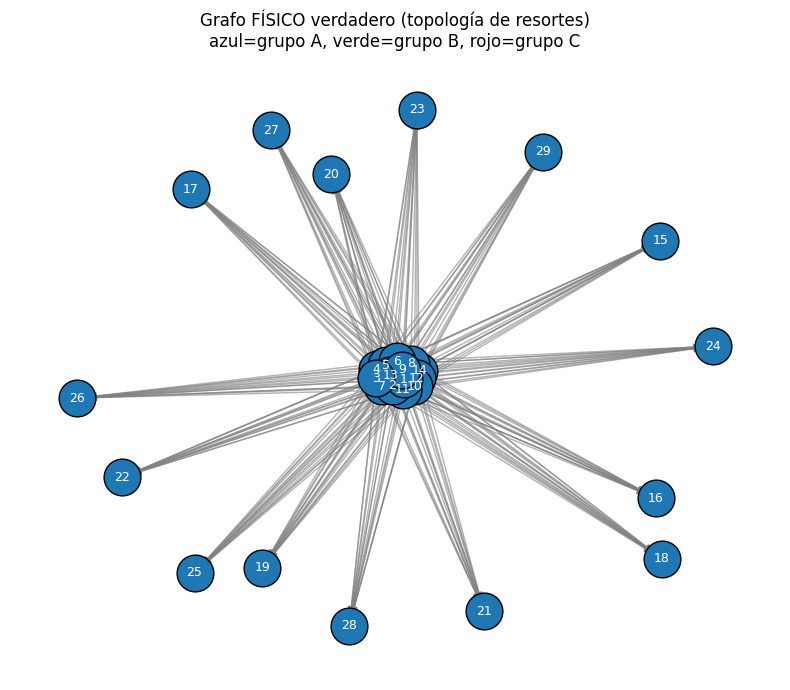

In [108]:
RANDOM_SEED = 7
pos = nx.spring_layout(G, seed=RANDOM_SEED, k=0.6)
# colores_nodo = [colores_grupo[grupo_de[n]] for n in G_fisico.nodes()]
# pesos_arista = [G_fisico[u][v]["weight"] * 5 for u, v in G_fisico.edges()]

plt.figure(figsize=(8, 7))
nx.draw_networkx_nodes(G, pos, node_size=700, edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white")
nx.draw_networkx_edges(G, pos, alpha=0.6, edge_color="gray")
plt.title("Grafo FÍSICO verdadero (topología de resortes)\nazul=grupo A, verde=grupo B, rojo=grupo C")
plt.axis("off")
plt.tight_layout()
plt.show()

## Fase 4: Modelado y Toma de Decisiones (CRISP-DM)


### Problema de Negocio: La Falla del Nodo 214